### To build Deep Learning Model pipelines we need 2 Libraries

1. Tensorflow -> very old library -> need to write every funtion manually -> Lengthy codes
2. Keras 2.0 -> is built on top of Tensorflow .Dependent on Tensorflow
3. Keras 3.0 -> is independent of Tensorflow

## 1.Installing Keras

In [1]:
pip install keras

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### ======================================================================

## Let's build our first Artificial Deep Neural Network

## 1.Import Necessary Libraries

In [10]:
import keras
from matplotlib import pyplot as plt
import pandas as pd

## 2. Data Collection

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


## 3.Data Undertsanding 

In [5]:
x_train.shape,y_train.shape

((60000, 28, 28), (60000,))

In [6]:
x_test.shape,y_test.shape

((10000, 28, 28), (10000,))

In [7]:
assert x_train.shape == (60000, 28, 28)
assert x_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

### 3.1 Let's see how one image looks like 

In [12]:
pd.set_option('display.max_columns',30)

In [13]:
pd.DataFrame(x_train[10000])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,29,150,195,254,255,254,176,193,150,96,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,48,166,224,253,253,234,196,253,253,253,253,233,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,93,244,249,253,187,46,10,8,4,10,194,253,253,233,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,107,253,253,230,48,0,0,0,0,0,192,253,253,156,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,3,20,20,15,0,0,0,0,0,43,224,253,245,74,0,0,0,0,0,0,0,0,0


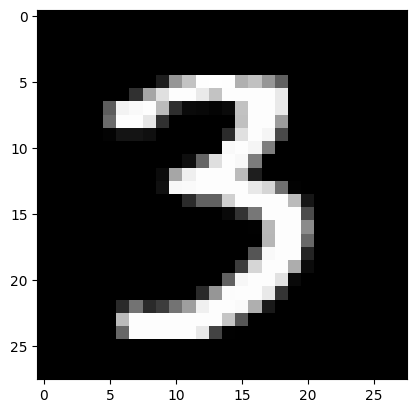

In [15]:
plt.imshow(x_train[10000],cmap="grey")

## 4. Data Preparation

#### Let's normalize this for fast processing

In [16]:
x_train=x_train/255.0
x_test=x_test/255.0

In [17]:
x_train.min(),x_train.max()

(np.float64(0.0), np.float64(1.0))

In [18]:
x_test.min(),x_test.max()

(np.float64(0.0), np.float64(1.0))

## 5.Model Building

In [22]:
from keras.models import Sequential
from keras.layers import Flatten,Dense

In [26]:
model=Sequential()
model.add(layer=Flatten())
model.add(Dense( units=100,activation="relu"))
model.add(Dense(units=10,activation="softmax"))
# model.summary()

In [27]:
model.compile(optimizer='rmsprop',loss="sparse_categorical_crossentropy",metrics=["sparse_categorical_accuracy"])

## 6. Model Training || 7.Model Testing || Model Evaluation

In [29]:
model.fit( x=x_train,y=y_train,batch_size=None,epochs=10,validation_data=(x_test,y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 18ms/step - loss: 0.2664 - sparse_categorical_accuracy: 0.9249 - val_loss: 0.1397 - val_sparse_categorical_accuracy: 0.9581
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 0.1249 - sparse_categorical_accuracy: 0.9632 - val_loss: 0.1203 - val_sparse_categorical_accuracy: 0.9630
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 0.0902 - sparse_categorical_accuracy: 0.9732 - val_loss: 0.0949 - val_sparse_categorical_accuracy: 0.9716
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - loss: 0.0722 - sparse_categorical_accuracy: 0.9790 - val_loss: 0.0860 - val_sparse_categorical_accuracy: 0.9738
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - loss: 0.0604 - sparse_categorical_accuracy: 0.9820 - val_loss: 0.0944 - val_sparse_categorical_accuracy: 0.9754
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 0.0517 - sparse_categorical_accuracy: 0.9853 - val_loss: 0.0815 - val_sparse_categoric

In [30]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)                  │ (32, 784)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (32, 100)                   │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (32, 10)                    │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 159,022 (621.18 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 79,512 (310.59 KB)

## 9. Manual Model Prediction

In [33]:
y_pred=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [34]:
y_pred[400]

array([2.7312827e-04, 2.9478034e-14, 9.9972659e-01, 6.7378578e-09,
       1.6970206e-16, 7.2893774e-13, 8.4094353e-14, 2.3590177e-11,
       2.0348772e-07, 6.5788785e-12], dtype=float32)

In [35]:
x_test[400]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

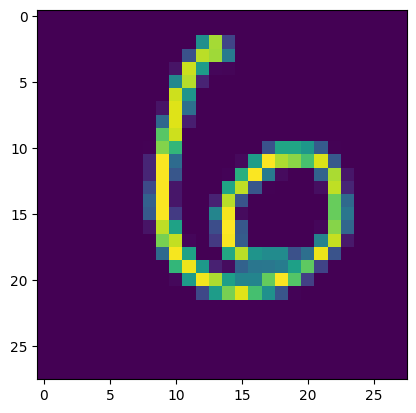

In [38]:
plt.imshow(x_test[100])

In [39]:
import numpy as np
np.argmax(y_pred[100])

np.int64(6)

## ===================================================

## Final Point : Let's test for outside new data

### Step:1 : Let's take out the model intelligence file

In [40]:
model.save("digits_intel.h5")

## Step 2: Load Image

In [65]:
from PIL import Image
img_path=r"F:\1 Datascience & AI course\Screenshot 2026-09-13 192059.png"
image=Image.open(img_path)
image=image.convert(mode='L')
image.resize(size=(28,28))

In [66]:
from PIL import Image
img_path=r"F:\1 Datascience & AI course\Screenshot 2026-09-13 192059.png"
image=Image.open(img_path).convert(mode='L').resize(size=(28,28))
image=np.array(image)

### Step 3: Let's do the prediction

In [67]:
from keras.models import load_model
digits_brain=load_model("digits_intel.h5")

In [68]:
def predict_image(image):
    image=image/255.0
    image=np.expand_dims(a=image,axis=0)
    print(image.shape)
    prediction=digits_brain.predict(image)
    return np.argmax(prediction)

    

In [69]:
predict_image(image)

(1, 28, 28)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


np.int64(6)